<a href="https://colab.research.google.com/github/evanz1223/Car-Price-Idetification-Through-Linear-Regression/blob/main/automobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error



In [2]:
pip install ucimlrepo

In [46]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
automobile = fetch_ucirepo(id=10)

# data (as pandas dataframes)
X = automobile.data.features
# Set y to 'price' and then remove 'price' from X
y = X['price']
X = X.drop('price', axis=1)

# metadata
print(automobile.metadata)

# variable information
print(automobile.variables)

{'uci_id': 10, 'name': 'Automobile', 'repository_url': 'https://archive.ics.uci.edu/dataset/10/automobile', 'data_url': 'https://archive.ics.uci.edu/static/public/10/data.csv', 'abstract': "From 1985 Ward's Automotive Yearbook", 'area': 'Other', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 205, 'num_features': 25, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['symboling'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1985, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5B01C', 'creators': ['Jeffrey Schlimmer'], 'intro_paper': None, 'additional_info': {'summary': 'This data set consists of three types of entities: (a) the specification of an auto in terms of various characteristics, (b) its assigned insurance risk rating, (c) its normalized losses in use as compared to other cars.  The second rating corresponds to the degree to which th

In [4]:
X.head()

,price,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,fuel-system,engine-size,...,length,wheel-base,engine-location,drive-wheels,body-style,num-of-doors,aspiration,fuel-type,make,normalized-losses
0,13495.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
1,16500.0,27,21,5000.0,111.0,9.0,2.68,3.47,mpfi,130,...,168.8,88.6,front,rwd,convertible,2.0,std,gas,alfa-romero,NaN
2,16500.0,26,19,5000.0,154.0,9.0,3.47,2.68,mpfi,152,...,171.2,94.5,front,rwd,hatchback,2.0,std,gas,alfa-romero,NaN
3,13950.0,30,24,5500.0,102.0,10.0,3.40,3.19,mpfi,109,...,176.6,99.8,front,fwd,sedan,4.0,std,gas,audi,164.0
4,17450.0,22,18,5500.0,115.0,8.0,3.40,3.19,mpfi,136,...,176.6,99.4,front,4wd,sedan,4.0,std,gas,audi,164.0


In [70]:
from sklearn.model_selection import train_test_split

# Calculate missing values percentage for each column in X
missing_percentages = X.isnull().sum() / len(X) * 100

# Drop columns with more than 30% missing values (arbitrary threshold for simplicity)
# This is done to simplify the example; a more robust approach might use imputation
columns_to_drop = missing_percentages[missing_percentages > 30].index.tolist()
X_processed = X.drop(columns=columns_to_drop)

# Impute remaining numerical missing values with the mean
# Ensure columns are numeric before imputation
for col in X_processed.select_dtypes(include=np.number).columns:
    if X_processed[col].isnull().any():
        X_processed[col] = pd.to_numeric(X_processed[col], errors='coerce')
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean()) # Fixed FutureWarning

# Handle categorical features using one-hot encoding
# drop_first=True avoids multicollinearity
X_processed = pd.get_dummies(X_processed, drop_first=True)

# Align X_processed and y and drop rows where 'y' has NaN values
# First, combine them temporarily to easily drop rows with NaN in 'y'
combined_data = pd.concat([X_processed, y.rename('target_price')], axis=1)
combined_data.dropna(subset=['target_price'], inplace=True)

X_processed = combined_data.drop('target_price', axis=1)
y = combined_data['target_price']


# Now, split the processed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training target shape: {y_train.shape}')
print(f'Testing target shape: {y_test.shape}')

Training features shape: (160, 59)
Testing features shape: (41, 59)
Training target shape: (160,)
Testing target shape: (41,)


### Feature Engineering

Let's create some new features that might help the model capture more complex relationships in the data.

In [129]:
# Ensure all columns used for feature engineering are numeric
for col in ['horsepower', 'curb-weight', 'engine-size']:
    if col in X_processed.columns:
        X_processed[col] = pd.to_numeric(X_processed[col], errors='coerce')

# Fill any NaNs that might have been introduced by to_numeric (e.g., if a column was entirely non-numeric)
for col in ['horsepower', 'curb-weight', 'engine-size']:
    if col in X_processed.columns and X_processed[col].isnull().any():
        X_processed[col] = X_processed[col].fillna(X_processed[col].mean())

# Create new features
if 'horsepower' in X_processed.columns and 'curb-weight' in X_processed.columns:
    X_processed['horsepower_to_weight_ratio'] = X_processed['horsepower'] / X_processed['curb-weight']

if 'engine-size' in X_processed.columns:
    X_processed['engine_size_sq'] = X_processed['engine-size'] ** 2

if 'horsepower' in X_processed.columns:
    X_processed['horsepower_sq'] = X_processed['horsepower'] ** 2

print(f"New features added. X_processed shape: {X_processed.shape}")

New features added. X_processed shape: (201, 62)


### Re-split and Re-scale Data

Now that we have new features, we need to re-split the data into training and testing sets and re-apply scaling to both features (X) and the target (y).

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Re-split the processed data with new features
X_train_keras, X_test_keras, y_train_keras, y_test_keras = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Re-scale features (X)
scaler_keras = StandardScaler()
X_train_scaled_keras = scaler_keras.fit_transform(X_train_keras)
X_test_scaled_keras = scaler_keras.transform(X_test_keras)

# Re-scale target variable (y)
y_scaler_keras = StandardScaler()
y_train_scaled_keras = y_scaler_keras.fit_transform(y_train_keras.to_frame()).flatten()
y_test_scaled_keras = y_scaler_keras.transform(y_test_keras.to_frame()).flatten()

# Assert no NaNs before training
assert not np.isnan(X_train_scaled_keras).any(), "NaNs found in X_train_scaled_keras. Check preprocessing."
assert not np.isnan(y_train_scaled_keras).any(), "NaNs found in y_train_scaled_keras. Check preprocessing."

print(f'Training features shape (after feature engineering): {X_train_scaled_keras.shape}')
print(f'Testing features shape (after feature engineering): {X_test_scaled_keras.shape}')

Training features shape (after feature engineering): (160, 62)
Testing features shape (after feature engineering): (41, 62)


### Re-train Keras Model with Engineered Features

We'll now redefine and retrain the Keras model using the updated and scaled dataset with the newly engineered features. We'll use the same architecture and early stopping mechanism as before.

In [131]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the Keras model with updated input shape
model_fe = Sequential([
    Input(shape=(X_train_scaled_keras.shape[1],)), # Use updated X_train_scaled_keras shape
    Dense(128, activation='leaky_relu'),
    Dense(64, activation='leaky_relu'),
    Dense(32, activation='leaky_relu'),
    Dense(1) # Output layer for regression (price)
])

# Compile the model
opt_fe = Adam(learning_rate=0.001)
model_fe.compile(
    optimizer=opt_fe,
    loss='mean_squared_error',
    metrics=['mae']
)

# Stop training automatically when validation loss stops dropping
early_stop_fe = EarlyStopping(
    monitor='val_loss',
    patience=15,          # Number of epochs to wait for an improvement before stopping
    restore_best_weights=True  # Keeps the weights from the epoch with the lowest MSE
)

history_fe = model_fe.fit(
    X_train_scaled_keras, y_train_scaled_keras, # Use scaled y for training
    epochs=1000,          # Set a high ceiling
    batch_size=32,
    validation_data=(X_test_scaled_keras, y_test_scaled_keras), # Use scaled y for validation
    callbacks=[early_stop_fe],
    shuffle=True
)


Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.7336 - mae: 0.6711 - val_loss: 0.9756 - val_mae: 0.7229
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.2315 - mae: 0.3551 - val_loss: 0.4246 - val_mae: 0.4812
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1835 - mae: 0.3192 - val_loss: 0.3696 - val_mae: 0.4208
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0886 - mae: 0.2274 - val_loss: 0.3497 - val_mae: 0.3931
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0791 - mae: 0.2160 - val_loss: 0.3114 - val_mae: 0.3776
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0634 - mae: 0.1967 - val_loss: 0.2344 - val_mae: 0.3146
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0410 - mae: 0.1529 - val_loss: 0.2023 - val_mae: 0.2856
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0355 - mae: 0.1405 - val_loss: 0.1969 - val_mae: 0.2829
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.02

### Evaluate Keras Model with Engineered Features

Let's evaluate the performance of the model after incorporating feature engineering.

In [133]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions with the Keras model (with feature engineering) on the scaled test data
y_pred_scaled_fe_keras = model_fe.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_fe_keras = y_scaler_keras.inverse_transform(y_pred_scaled_fe_keras).flatten()
y_test_original_fe = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

# Calculate evaluation metrics
mse_fe_keras = mean_squared_error(y_test_original_fe, y_pred_fe_keras)
mae_fe_keras = mean_absolute_error(y_test_original_fe, y_pred_fe_keras)

print(f'Keras Model (with Feature Engineering) - Test MSE (original scale): {mse_fe_keras:.2f}')
print(f'Keras Model (with Feature Engineering) - Test MAE (original scale): {mae_fe_keras:.2f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Keras Model (with Feature Engineering) - Test MSE (original scale): 7030006.29
Keras Model (with Feature Engineering) - Test MAE (original scale): 1722.66


In [ ]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense

# Redefine the RegressionHyperModel as it might have been cleared from memory
class RegressionHyperModel(kt.HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(self.input_shape,)))

        # Tune the number of units in the first Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_1', min_value=32, max_value=256, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the second Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_2', min_value=32, max_value=128, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the third Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_3', min_value=16, max_value=64, step=16),
            activation='leaky_relu'
        ))
        model.add(keras.layers.Dense(1)) # Output layer for regression

        # Tune the learning rate for the Adam optimizer
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        model.compile(
            optimizer=optimizer,
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

# Instantiate the HyperModel with the (possibly new) input shape from feature engineering
hypermodel = RegressionHyperModel(input_shape=X_train_scaled_keras.shape[1])

# Set up the tuner (e.g., RandomSearch or Hyperband)
tuner = kt.RandomSearch(
    hypermodel,
    objective='val_mae', # Minimize validation MAE
    max_trials=100,       # Number of hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each combination (for robustness)
    directory='keras_tuner_dir',
    project_name='car_price_prediction_revisited',
    overwrite=True # Overwrite previous search results
)

# Display a summary of the search space
tuner.search_space_summary()

# Define early stopping callback (if not already defined, or redefine to ensure consistency)
early_stop_tuner = EarlyStopping(
    monitor='val_loss',
    patience=15,          # Number of epochs to wait for an improvement before stopping
    restore_best_weights=True  # Keeps the weights from the epoch with the lowest MSE
)

# Run the hyperparameter search
tuner.search(
    X_train_scaled_keras, y_train_scaled_keras,
    epochs=50, # Set epochs for the tuner search (can be lower than final training)
    validation_data=(X_test_scaled_keras, y_test_scaled_keras),
    callbacks=[early_stop_tuner]
)

Trial 30 Complete [00h 00m 22s]
val_mae: 0.2629523351788521

Best val_mae So Far: 0.22330476343631744
Total elapsed time: 00h 09m 52s

Search: Running Trial #31

Value             |Best Value So Far |Hyperparameter
224               |64                |units_1
32                |64                |units_2
32                |64                |units_3
0.00017776        |0.0076939         |learning_rate

Epoch 1/50


In [135]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get the best hyperparameters found by the tuner
best_hps_revisited = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found in revisited tuning:")
for hp_name, hp_value in best_hps_revisited.values.items():
    print(f"  {hp_name}: {hp_value}")

# Build the best model with the optimal hyperparameters
best_model_revisited = tuner.get_best_models(num_models=1)[0]

best_model_revisited.summary()

# Evaluate the best model on the test data
y_pred_scaled_best_revisited = best_model_revisited.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_best_original_revisited = y_scaler_keras.inverse_transform(y_pred_scaled_best_revisited).flatten()
y_test_original_best_revisited = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

mse_best_revisited = mean_squared_error(y_test_original_best_revisited, y_pred_best_original_revisited)
mae_best_revisited = mean_absolute_error(y_test_original_best_revisited, y_pred_best_original_revisited)

print(f'Tuned Keras Model (Revisited) - Test MSE (original scale): {mse_best_revisited:.2f}')
print(f'Tuned Keras Model (Revisited) - Test MAE (original scale): {mae_best_revisited:.2f}')


Best hyperparameters found in revisited tuning:
  units_1: 256
  units_2: 96
  units_3: 32
  learning_rate: 0.003943919476639352


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,937 (171.63 KB)

 Trainable params: 43,937 (171.63 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Tuned Keras Model (Revisited) - Test MSE (original scale): 4319364.02
Tuned Keras Model (Revisited) - Test MAE (original scale): 1489.67


In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [61]:
scaler.fit(X_train)


StandardScaler()

In [62]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
X_train.head()

,highway-mpg,city-mpg,peak-rpm,horsepower,compression-ratio,stroke,bore,engine-size,num-of-cylinders,curb-weight,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
202,23,18,5500.0,134.0,8.8,2.87,3.58,173,6,3012,...,False,False,False,False,False,False,False,False,False,True
39,33,27,5800.0,86.0,9.0,3.58,3.15,110,4,2304,...,False,False,False,False,False,False,False,False,False,False
25,38,31,5500.0,68.0,9.4,3.23,2.97,90,4,1989,...,False,False,False,False,False,False,False,False,False,False
125,27,19,5500.0,143.0,9.5,3.11,3.94,151,4,2778,...,False,False,False,True,False,False,False,False,False,False
200,28,23,5400.0,114.0,9.5,3.15,3.78,141,4,2952,...,False,False,False,False,False,False,False,False,False,True


In [64]:
X_train_scaled

array([[-1.16471216, -1.15657364,  0.77851556, ..., -0.42008403,
        -0.24413654,  3.680415  ],
       [ 0.33451508,  0.27056093,  1.40921957, ..., -0.42008403,
        -0.24413654, -0.27170849],
       [ 1.08412869,  0.90484296,  0.77851556, ..., -0.42008403,
        -0.24413654, -0.27170849],
       ...,
       [ 0.93420597,  0.90484296,  0.14781154, ..., -0.42008403,
        -0.24413654, -0.27170849],
       [ 0.4844378 ,  0.27056093,  0.25292888, ..., -0.42008403,
         4.09606858, -0.27170849],
       [-1.16471216, -1.31514415,  0.14781154, ..., -0.42008403,
        -0.24413654, -0.27170849]])

In [47]:
# This cell is no longer needed as 'price' is now directly assigned to 'y'.

In [48]:
# This cell is no longer needed as 'price' is now directly assigned to 'y'.

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
model = LinearRegression()

In [67]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [68]:
model.fit(X_train, y_train)

LinearRegression()

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Make predictions with the Keras model on the scaled test data
y_pred_scaled_keras = model.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_keras = y_scaler_keras.inverse_transform(y_pred_scaled_keras).flatten()
y_test_original = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

# Calculate evaluation metrics
mse_keras = mean_squared_error(y_test_original, y_pred_keras)
mae_keras = mean_absolute_error(y_test_original, y_pred_keras)

print(f'Keras Model - Test MSE (original scale): {mse_keras:.2f}')
print(f'Keras Model - Test MAE (original scale): {mae_keras:.2f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Keras Model - Test MSE (original scale): 7109560.91
Keras Model - Test MAE (original scale): 1806.08


In [119]:
pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00


In [120]:
from tensorflow import keras
from keras_tuner import HyperModel, RandomSearch

class RegressionHyperModel(HyperModel):
    def __init__(self, input_shape):
        self.input_shape = input_shape

    def build(self, hp):
        model = keras.Sequential()
        model.add(keras.layers.Input(shape=(self.input_shape,)))

        # Tune the number of units in the first Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_1', min_value=32, max_value=256, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the second Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_2', min_value=32, max_value=128, step=32),
            activation='leaky_relu'
        ))
        # Tune the number of units in the third Dense layer
        model.add(keras.layers.Dense(
            units=hp.Int('units_3', min_value=16, max_value=64, step=16),
            activation='leaky_relu'
        ))
        model.add(keras.layers.Dense(1)) # Output layer for regression

        # Tune the learning rate for the Adam optimizer
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        model.compile(
            optimizer=optimizer,
            loss='mean_squared_error',
            metrics=['mae']
        )
        return model

# Instantiate the HyperModel
hypermodel = RegressionHyperModel(input_shape=X_train_scaled_keras.shape[1])


In [121]:
# Set up the tuner (e.g., RandomSearch or Hyperband)
tuner = RandomSearch(
    hypermodel,
    objective='val_mae', # Minimize validation MAE
    max_trials=10,       # Number of hyperparameter combinations to try
    executions_per_trial=2, # Number of models to train for each combination (for robustness)
    directory='keras_tuner_dir',
    project_name='car_price_prediction'
)

# Display a summary of the search space
tuner.search_space_summary()

# Run the hyperparameter search
# Use the early_stop callback defined previously
tuner.search(
    X_train_scaled_keras, y_train_scaled_keras,
    epochs=50, # Set epochs for the tuner search (can be lower than final training)
    validation_data=(X_test_scaled_keras, y_test_scaled_keras),
    callbacks=[early_stop]
)


Trial 10 Complete [00h 00m 12s]
val_mae: 0.3328270763158798

Best val_mae So Far: 0.2256697118282318
Total elapsed time: 00h 02m 17s


In [122]:
# Get the best hyperparameters found by the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found:")
for hp_name, hp_value in best_hps.values.items():
    print(f"  {hp_name}: {hp_value}")

# Build the best model with the optimal hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()


Best hyperparameters found:
  units_1: 192
  units_2: 64
  units_3: 48
  learning_rate: 0.004985246236342349


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 192)            │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,041 (105.63 KB)

 Trainable params: 27,041 (105.63 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Evaluate the best model on the test data
y_pred_scaled_best = best_model.predict(X_test_scaled_keras)

# Inverse transform the scaled predictions and actual values to the original price scale
y_pred_best_original = y_scaler_keras.inverse_transform(y_pred_scaled_best).flatten()
y_test_original_best = y_scaler_keras.inverse_transform(y_test_scaled_keras.reshape(-1, 1)).flatten()

mse_best = mean_squared_error(y_test_original_best, y_pred_best_original)
mae_best = mean_absolute_error(y_test_original_best, y_pred_best_original)

print(f'Tuned Keras Model - Test MSE (original scale): {mse_best:.2f}')
print(f'Tuned Keras Model - Test MAE (original scale): {mae_best:.2f}')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Tuned Keras Model - Test MSE (original scale): 5576028.67
Tuned Keras Model - Test MAE (original scale): 1473.69


In [78]:

Y_pred = model.predict(X_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [79]:
print("y_test shape:", getattr(y_test, 'shape', len(y_test)))
print("Y_pred shape:", getattr(Y_pred, 'shape', len(Y_pred)))


y_test shape: (41,)
Y_pred shape: (160, 1)


In [80]:
import torch

# Convert X_train to a NumPy array if it's a PyTorch Tensor
if isinstance(X_train, torch.Tensor):
    X_train_np = X_train.detach().cpu().numpy()
else:
    X_train_np = X_train # Assume it's already a DataFrame or NumPy array

X_1feature_train = X_train_np.iloc[:, 0:1]

In [83]:
from sklearn.linear_model import LinearRegression

# Create a new LinearRegression model for the single feature
model_1feature = LinearRegression()

# Fit the new model using only the first feature
model_1feature.fit(X_1feature_train, y_train)

# Make predictions with the 1-feature model
y_pred_1feature = model_1feature.predict(X_1feature_train)

# Calculate mean squared error
mse_1feature = mean_squared_error(y_train, y_pred_1feature)
print(f"Mean Squared Error for 1-feature model: {mse_1feature}")

Mean Squared Error for 1-feature model: 22755917.883286837


In [84]:
print(X_train.shape, y_train.shape, X_1feature_train.shape)


(160, 59) (160,) (160, 1)


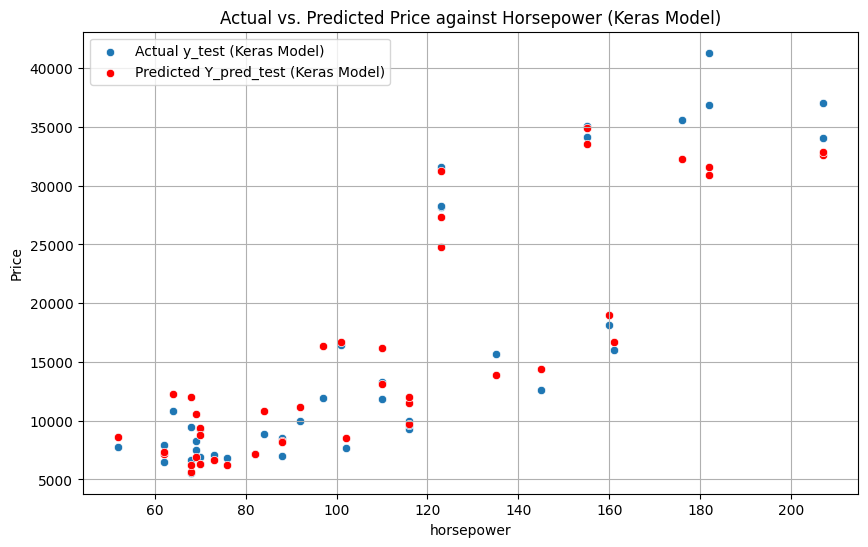

In [126]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_keras["horsepower"], y=y_test_original, label='Actual y_test (Keras Model)')
sns.scatterplot(x=X_test_keras["horsepower"], y=y_pred_keras, color="red", label='Predicted Y_pred_test (Keras Model)')
plt.title('Actual vs. Predicted Price against Horsepower (Keras Model)')
plt.xlabel('horsepower')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [86]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error


In [114]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Re-run data split and scaling to ensure consistency for Keras model
# This assumes X_processed and y (original target) are correctly defined upstream
X_train_keras, X_test_keras, y_train_keras, y_test_keras = train_test_split(X_processed, y, test_size=0.2, random_state=42)

scaler_keras = StandardScaler()
X_train_scaled_keras = scaler_keras.fit_transform(X_train_keras)
X_test_scaled_keras = scaler_keras.transform(X_test_keras)

# New: Scale the target variable (y) as well to prevent NaN loss with large values
y_scaler_keras = StandardScaler()
# .to_frame() is used because StandardScaler expects 2D input
y_train_scaled_keras = y_scaler_keras.fit_transform(y_train_keras.to_frame()).flatten()
y_test_scaled_keras = y_scaler_keras.transform(y_test_keras.to_frame()).flatten()

# Assert no NaNs before training
assert not np.isnan(X_train_scaled_keras).any(), "NaNs found in X_train_scaled_keras. Check preprocessing."
assert not np.isnan(y_train_scaled_keras).any(), "NaNs found in y_train_scaled_keras. Check preprocessing."

# Define the Keras model
model = Sequential([
    Input(shape=(X_train_scaled_keras.shape[1],)), # Use X_train_scaled_keras shape
    Dense(128, activation='leaky_relu'),
    Dense(64, activation='leaky_relu'),
    Dense(32, activation='leaky_relu'),
    Dense(1) # Output layer should be 1 for regression (price)
])

# Compile the model
opt = Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss='mean_squared_error',
    metrics=['mae']
)

# Stop training automatically when validation loss stops dropping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,          # Number of epochs to wait for an improvement before stopping
    restore_best_weights=True  # Keeps the weights from the epoch with the lowest MSE
)

history = model.fit(
    X_train_scaled_keras, y_train_scaled_keras, # Use scaled y for training
    epochs=1000,          # Set a high ceiling
    batch_size=32,
    validation_data=(X_test_scaled_keras, y_test_scaled_keras), # Use scaled y for validation
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 1.3938 - mae: 0.7206 - val_loss: 1.6320 - val_mae: 0.8385
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3856 - mae: 0.4329 - val_loss: 0.6479 - val_mae: 0.5495
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2781 - mae: 0.4032 - val_loss: 0.4186 - val_mae: 0.4558
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1748 - mae: 0.3207 - val_loss: 0.3470 - val_mae: 0.4094
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1017 - mae: 0.2406 - val_loss: 0.3461 - val_mae: 0.3978
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0810 - mae: 0.2134 - val_loss: 0.3133 - val_mae: 0.3758
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0667 - mae: 0.1945 - val_loss: 0.2675 - val_mae: 0.3421
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0491 - mae: 0.1669 - val_loss: 0.2283 - val_mae: 0.3232
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.039

In [89]:
# Try adding more neurons or an extra layer
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='leaky_relu'),  # Increased from 64
    Dense(64, activation='leaky_relu'),   # Increased from 32
    Dense(32, activation='leaky_relu'),   # New extra layer
    Dense(1)
])


In [113]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

# Re-run data split to ensure consistency for scikit-learn model
# This assumes X_processed and y (original target) are correctly defined upstream
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Ensure the model is LinearRegression and trained on the first 10 features
model = LinearRegression()
# Train the LinearRegression model on the first 10 features of the training data
model.fit(X_train_sk.iloc[:, :10], y_train_sk)

# 1. Slice the DataFrame to keep only the first 10 columns for X_test
X_test_fixed = X_test_sk.iloc[:, :10]

# 2. Run prediction using your LinearRegression model
Y_pred_test = model.predict(X_test_fixed)

# 3. Evaluate the model
mse_test = mean_squared_error(y_test_sk, Y_pred_test)
rmse_test = root_mean_squared_error(y_test_sk, Y_pred_test)

print(f'Full Model - Test MSE: {mse_test:.3f}')
print(f'Full Model - Test RMSE: {rmse_test:.3f}')

Full Model - Test MSE: 23205580.471
Full Model - Test RMSE: 4817.217


In [117]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. SETUP SIMULATED DATA
np.random.seed(42)
X_np = np.random.rand(1000, 10).astype(np.float32)
y_np = (X_np @ np.random.rand(10, 1) + 0.5 + np.random.normal(0, 0.1, (1000, 1))).astype(np.float32)

X_train, X_val = torch.tensor(X_np[:800]), torch.tensor(X_np[800:])
y_train, y_val = torch.tensor(y_np[:800]), torch.tensor(y_np[800:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# 2. MODEL WITH DROPOUT (FIXES OVERFITTING)
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(10, 64)
        self.dropout = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = RegressionModel()
criterion = nn.MSELoss()

# OPTIMIZER (FIXES EXPLODING STEPS)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. TRAINING LOOP WITH EARLY STOPPING
epochs = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # GRADIENT CLIPPING (FIXES EXPLODING GRADIENTS)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # VALIDATION MONITORING
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(val_loader.dataset)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    # EARLY STOPPING LOGIC
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at Epoch {epoch+1}. Validation MSE stopped decreasing.")
            break


Starting training...
Epoch 01/100 | Train MSE: 7.0110 | Val MSE: 5.0175
Epoch 05/100 | Train MSE: 0.1219 | Val MSE: 0.0225
Epoch 10/100 | Train MSE: 0.0783 | Val MSE: 0.0087
Epoch 15/100 | Train MSE: 0.0730 | Val MSE: 0.0085
Epoch 20/100 | Train MSE: 0.0664 | Val MSE: 0.0090
Epoch 25/100 | Train MSE: 0.0720 | Val MSE: 0.0086

Early stopping triggered at Epoch 26. Validation MSE stopped decreasing.


In [118]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Train the model instantly (NO epochs parameter)
model.fit(X_train, y_train)

# Evaluate your MSE
from sklearn.metrics import mean_squared_error
predictions = model.predict(X_val)
mse = mean_squared_error(y_val, predictions)
print(f"Validation MSE: {mse}")


Validation MSE: 0.008318576961755753


In [96]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# 1. SETUP SIMULATED DATA
np.random.seed(42)
X_np = np.random.rand(1000, 10).astype(np.float32)
y_np = (X_np @ np.random.rand(10, 1) + 0.5 + np.random.normal(0, 0.1, (1000, 1))).astype(np.float32)

X_train, X_val = torch.tensor(X_np[:800]), torch.tensor(X_np[800:])
y_train, y_val = torch.tensor(y_np[:800]), torch.tensor(y_np[800:])

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# 2. MODEL WITH DROPOUT (FIXES OVERFITTING)
class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(10, 64)
        self.dropout = nn.Dropout(p=0.2)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = RegressionModel()
criterion = nn.MSELoss()

# OPTIMIZER (FIXES EXPLODING STEPS)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 3. TRAINING LOOP WITH EARLY STOPPING
epochs = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

print("Starting training...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # GRADIENT CLIPPING (FIXES EXPLODING GRADIENTS)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # VALIDATION MONITORING
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(val_loader.dataset)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

    # EARLY STOPPING LOGIC
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at Epoch {epoch+1}. Validation MSE stopped decreasing.")
            break


Starting training...
Epoch 01/100 | Train MSE: 8.6314 | Val MSE: 6.7295
Epoch 05/100 | Train MSE: 0.1825 | Val MSE: 0.0686
Epoch 10/100 | Train MSE: 0.0966 | Val MSE: 0.0205
Epoch 15/100 | Train MSE: 0.0919 | Val MSE: 0.0099
Epoch 20/100 | Train MSE: 0.0785 | Val MSE: 0.0083
Epoch 25/100 | Train MSE: 0.0711 | Val MSE: 0.0108
Epoch 30/100 | Train MSE: 0.0722 | Val MSE: 0.0105
Epoch 35/100 | Train MSE: 0.0683 | Val MSE: 0.0084

Early stopping triggered at Epoch 36. Validation MSE stopped decreasing.
